# **Section 1: Data Loading & Decoding**

---



Load, Decode, and Split Data

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import classification_report, precision_recall_fscore_support

# Load and Decode 
(x_train_raw, y_train_imdb), (x_test_raw, y_test_imdb) = tf.keras.datasets.imdb.load_data()
word_index = tf.keras.datasets.imdb.get_word_index()
index2word = {i + 3: word for word, i in word_index.items()}
index2word[0], index2word[1], index2word[2] = '[pad]', '[bos]', '[oov]'

x_train_text = np.array([' '.join([index2word.get(idx, '[oov]') for idx in text]) for text in x_train_raw])
x_test_text = np.array([' '.join([index2word.get(idx, '[oov]') for idx in text]) for text in x_test_raw])

# Create Development Set 
x_train_full, x_dev_text, y_train_full, y_dev = train_test_split(
    x_train_text, y_train_imdb, test_size=0.2, random_state=42
)

# **Section 2: Part A (Traditional ML & Information Gain)**

---



Custom Vocabulary Selection (Information Gain)

In [ ]:
# Hyperparameters (Adjust these based on Development Data performance)
n = 100   # Most frequent
k = 100   # Most rare (document frequency threshold)
m = 1000  # Final vocabulary size (Information Gain)

# Frequency Filtering
cv_freq = CountVectorizer(binary=True, min_df=k)
X_freq = cv_freq.fit_transform(x_train_full)
words = cv_freq.get_feature_names_out()

doc_counts = np.asarray(X_freq.sum(axis=0)).flatten()

# Remove the n most frequent
top_n_indices = np.argsort(doc_counts)[-n:]
mask = np.ones(len(words), dtype=bool)
mask[top_n_indices] = False
filtered_words = words[mask]
X_filtered = X_freq[:, mask]

# Information Gain Selection 
# mutual_info_classif calculates Information Gain 
ig_scores = mutual_info_classif(X_filtered, y_train_full, discrete_features=True)
top_m_indices = np.argsort(ig_scores)[-m:]
final_vocabulary = filtered_words[top_m_indices]

# Final Vectorization 
vectorizer = CountVectorizer(binary=True, vocabulary=final_vocabulary)
X_train = vectorizer.transform(x_train_full).toarray()
X_dev = vectorizer.transform(x_dev_text).toarray()
X_test = vectorizer.transform(x_test_text).toarray()

Learning Curves Implementation

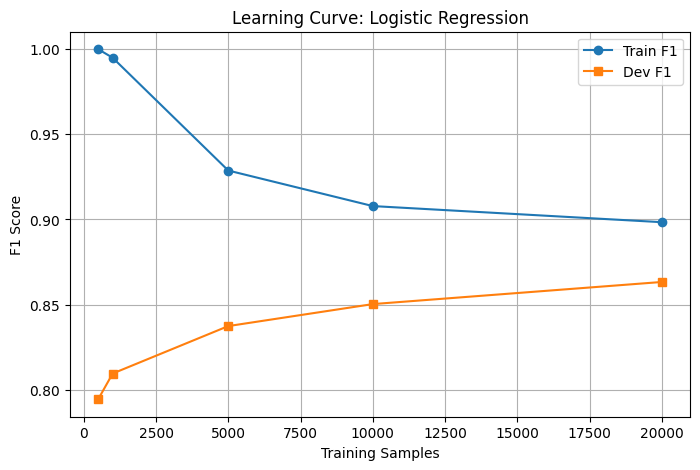

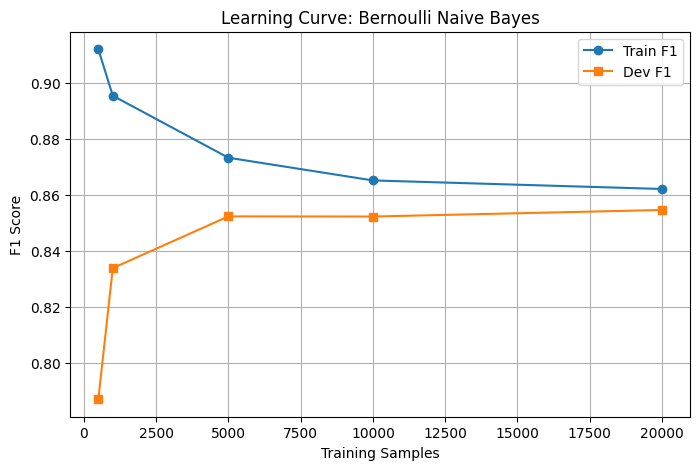

In [ ]:
def plot_learning_curves(model, name):
    train_sizes = [500, 1000, 5000, 10000, len(X_train)]
    results = {'train': [], 'dev': []}

    for size in train_sizes:
        model.fit(X_train[:size], y_train_full[:size])

        # Get metrics for Positive class (index 1)
        train_metrics = precision_recall_fscore_support(y_train_full[:size], model.predict(X_train[:size]), average='binary')
        dev_metrics = precision_recall_fscore_support(y_dev, model.predict(X_dev), average='binary')

        results['train'].append(train_metrics[2]) # F1 Score
        results['dev'].append(dev_metrics[2])

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, results['train'], 'o-', label='Train F1')
    plt.plot(train_sizes, results['dev'], 's-', label='Dev F1')
    plt.title(f'Learning Curve: {name}')
    plt.xlabel('Training Samples')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid(True)
    plt.show()

# Algorithm implementations 
lr_model = LogisticRegression(penalty='l2', max_iter=1000) # L2 Regularization [cite: 11]
nb_model = BernoulliNB() # Bernoulli Naive Bayes [cite: 8]

plot_learning_curves(lr_model, "Logistic Regression")
plot_learning_curves(nb_model, "Bernoulli Naive Bayes")

Final Evaluation (Test Data)

In [ ]:
# Final evaluation after training on all available training data
for name, model in [("Logistic Regression", lr_model), ("Naive Bayes", nb_model)]:
    model.fit(X_train, y_train_full)
    y_pred = model.predict(X_test)
    print(f"\n--- {name} Final Test Results ---")
    print(classification_report(y_test_imdb, y_pred, digits=4)) # Shows micro/macro averages


--- Logistic Regression Final Test Results ---
              precision    recall  f1-score   support

           0     0.8705    0.8560    0.8632     12500
           1     0.8584    0.8726    0.8654     12500

    accuracy                         0.8643     25000
   macro avg     0.8644    0.8643    0.8643     25000
weighted avg     0.8644    0.8643    0.8643     25000


--- Naive Bayes Final Test Results ---
              precision    recall  f1-score   support

           0     0.8474    0.8566    0.8520     12500
           1     0.8551    0.8458    0.8504     12500

    accuracy                         0.8512     25000
   macro avg     0.8512    0.8512    0.8512     25000
weighted avg     0.8512    0.8512    0.8512     25000



# **Section 3: Part B (Stacked Bidirectional RNN & GloVe)**

---



Model Architecture (Stacked Bidirectional RNN)

✅ Hardware Check: Training on cuda
⏳ Loading IMDB dataset...
⏳ Processing Embeddings...

🚀 Starting Training on GPU...
Epoch 1/10 | Train Loss: 0.4817 | Dev Loss: 0.3682
Epoch 2/10 | Train Loss: 0.3038 | Dev Loss: 0.3589
Epoch 3/10 | Train Loss: 0.2296 | Dev Loss: 0.3233
Epoch 4/10 | Train Loss: 0.1746 | Dev Loss: 0.3341
Epoch 5/10 | Train Loss: 0.1234 | Dev Loss: 0.3693
Epoch 6/10 | Train Loss: 0.0802 | Dev Loss: 0.4660
Epoch 7/10 | Train Loss: 0.0508 | Dev Loss: 0.5260
Epoch 8/10 | Train Loss: 0.0300 | Dev Loss: 0.5927
Epoch 9/10 | Train Loss: 0.0156 | Dev Loss: 0.6676
Epoch 10/10 | Train Loss: 0.0144 | Dev Loss: 0.7128


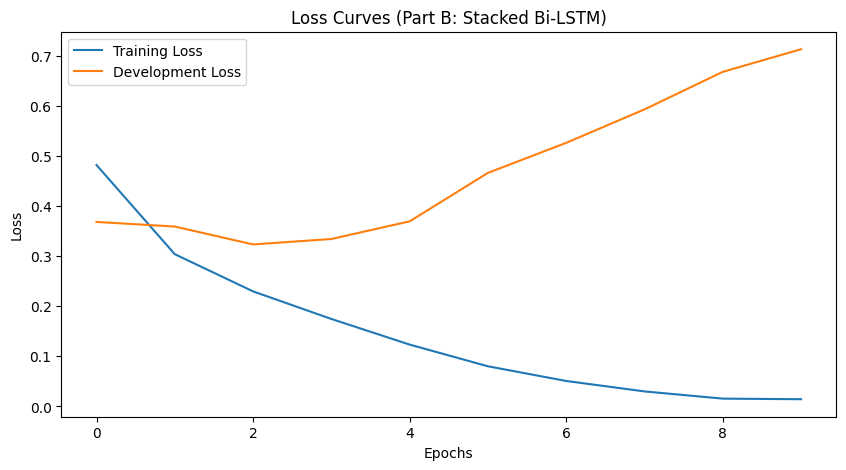


--- Final Test Results (Part B) ---
              precision    recall  f1-score   support

         0.0     0.8542    0.8546    0.8544     12500
         1.0     0.8545    0.8542    0.8543     12500

    accuracy                         0.8544     25000
   macro avg     0.8544    0.8544    0.8544     25000
weighted avg     0.8544    0.8544    0.8544     25000



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import requests
import zipfile
import os
import io
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# --- 1. GPU SETUP & HYPERPARAMETERS ---
# This line is critical for speed. It checks if the T4 is available.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Hardware Check: Training on {device}")

MAX_LEN = 200        # Max sequence length
VOCAB_SIZE = 10000   # Size of vocabulary
EMBED_DIM = 100      # Dimension of GloVe vectors
HIDDEN_DIM = 128     # Hidden units in LSTM
NUM_LAYERS = 2       # Stacked layers
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 0.001

#  DATA LOADING (IMDB) 
print("⏳ Loading IMDB dataset...")
(x_train_seq, y_train_full), (x_test_seq, y_test) = tf.keras.datasets.imdb.load_data(num_words=VOCAB_SIZE)

# Decode helper to map back to text (needed for GloVe mapping)
word_index = tf.keras.datasets.imdb.get_word_index()
index2word = {i + 3: word for word, i in word_index.items()}
index2word[0] = '<pad>'
index2word[1] = '<bos>'
index2word[2] = '<unk>'

def decode_reviews(sequences):
    return [' '.join([index2word.get(idx, '<unk>') for idx in seq]) for seq in sequences]

x_train_text = decode_reviews(x_train_seq)
x_test_text = decode_reviews(x_test_seq)

# Create Development Set
x_train_split, x_dev_split, y_train_split, y_dev_split = train_test_split(
    x_train_text, y_train_full, test_size=0.2, random_state=42
)

# --- 3. GLOVE EMBEDDINGS (Manual Download) ---
glove_file = 'glove.6B.100d.txt'
if not os.path.exists(glove_file):
    print(" Downloading GloVe embeddings (approx 1 min)...")
    url = "http://nlp.stanford.edu/data/glove.6B.zip"
    r = requests.get(url)
    z = zipfile.ZipFile(io.BytesIO(r.content))
    z.extractall()
    print(" GloVe Downloaded.")

print("Processing Embeddings...")
embeddings_index = {}
with open(glove_file, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

# Build Custom Vocabulary & Weight Matrix
all_words = [word for text in x_train_split for word in text.split()]
from collections import Counter
word_counts = Counter(all_words)
common_words = word_counts.most_common(VOCAB_SIZE - 2)

my_word_to_idx = {"<pad>": 0, "<unk>": 1}
for word, _ in common_words:
    my_word_to_idx[word] = len(my_word_to_idx)

# Initialize Embedding Matrix (on CPU first, moved to GPU by model later)
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM))
for word, i in my_word_to_idx.items():
    if i < VOCAB_SIZE:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector
        else:
            embedding_matrix[i] = np.random.normal(scale=0.6, size=(EMBED_DIM,))

weights_tensor = torch.tensor(embedding_matrix, dtype=torch.float32)

# --- 4. TENSOR PREPARATION ---
def vectorize_text(texts, word_map, max_len):
    tensor_data = []
    for text in texts:
        tokens = text.split()
        seq = [word_map.get(t, 1) for t in tokens[:max_len]]
        if len(seq) < max_len:
            seq += [0] * (max_len - len(seq))
        tensor_data.append(seq)
    return torch.tensor(tensor_data, dtype=torch.long)

# Create Tensors
X_train_t = vectorize_text(x_train_split, my_word_to_idx, MAX_LEN)
y_train_t = torch.tensor(y_train_split, dtype=torch.float32).unsqueeze(1)
X_dev_t = vectorize_text(x_dev_split, my_word_to_idx, MAX_LEN)
y_dev_t = torch.tensor(y_dev_split, dtype=torch.float32).unsqueeze(1)
X_test_t = vectorize_text(x_test_text, my_word_to_idx, MAX_LEN)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Loaders (Pin memory helps transfer to GPU faster)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
dev_loader = DataLoader(TensorDataset(X_dev_t, y_dev_t), batch_size=BATCH_SIZE, pin_memory=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=BATCH_SIZE, pin_memory=True)

#  MODEL ARCHITECTURE 
class StackedBiLSTM(nn.Module):
    def __init__(self, weights, hidden_dim, num_layers):
        super(StackedBiLSTM, self).__init__()
        # Embedding Layer
        self.embedding = nn.Embedding.from_pretrained(weights, freeze=False, padding_idx=0)
        # Stacked Bi-LSTM
        self.lstm = nn.LSTM(EMBED_DIM, hidden_dim, num_layers=num_layers,
                            bidirectional=True, batch_first=True, dropout=0.5)
        # FC Layer (Input is Hidden*2 because of bidirectional)
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded)
        # Global Max Pooling
        pooled, _ = torch.max(lstm_out, dim=1)
        return self.sigmoid(self.fc(pooled))

# Initialize and MOVE TO GPU
model = StackedBiLSTM(weights_tensor, HIDDEN_DIM, NUM_LAYERS).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.BCELoss()

# --- 6. TRAINING LOOP (GPU OPTIMIZED) ---
print("\n🚀 Starting Training on GPU...")
train_losses, dev_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    batch_losses = []

    for inputs, targets in train_loader:
        # CRITICAL: Move data to GPU
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    # Validation Phase
    model.eval()
    val_losses = []
    with torch.no_grad():
        for inputs, targets in dev_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_losses.append(loss.item())

    avg_train_loss = np.mean(batch_losses)
    avg_val_loss = np.mean(val_losses)
    train_losses.append(avg_train_loss)
    dev_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Dev Loss: {avg_val_loss:.4f}")

# --- 7. PLOTTING & EVALUATION ---
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(dev_losses, label='Development Loss')
plt.title('Loss Curves (Part B: Stacked Bi-LSTM)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Final Test Eval
model.eval()
all_preds = []
all_targets = []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        preds = model(inputs)
        all_preds.extend((preds > 0.5).int().cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

print("\n--- Final Test Results (Part B) ---")
print(classification_report(all_targets, all_preds, digits=4))

Part C

✅ Hardware Check: Training on cuda
⏳ Downloading FashionMNIST Dataset...


100%|██████████| 26.4M/26.4M [00:01<00:00, 13.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.76MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.3MB/s]


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 163MB/s]



🚀 Starting Training (CNN)...
Epoch 1/10 | Train Loss: 0.6260 | Dev Loss: 0.4807
Epoch 2/10 | Train Loss: 0.4421 | Dev Loss: 0.3498
Epoch 3/10 | Train Loss: 0.3879 | Dev Loss: 0.3562
Epoch 4/10 | Train Loss: 0.3624 | Dev Loss: 0.3068
Epoch 5/10 | Train Loss: 0.3360 | Dev Loss: 0.2921
Epoch 6/10 | Train Loss: 0.3170 | Dev Loss: 0.3177
Epoch 7/10 | Train Loss: 0.3029 | Dev Loss: 0.2889
Epoch 8/10 | Train Loss: 0.3009 | Dev Loss: 0.3045
Epoch 9/10 | Train Loss: 0.2800 | Dev Loss: 0.2720
Epoch 10/10 | Train Loss: 0.2607 | Dev Loss: 0.2538


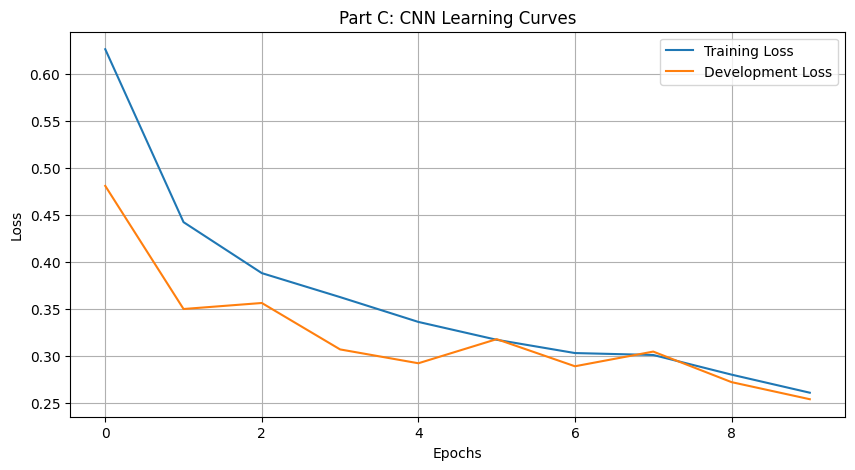


⏳ Running Final Evaluation on Test Set...

--- FashionMNIST Final Test Results ---
              precision    recall  f1-score   support

 T-shirt/top     0.8348    0.8790    0.8563      1000
     Trouser     0.9939    0.9810    0.9874      1000
    Pullover     0.8096    0.8930    0.8493      1000
       Dress     0.9166    0.9230    0.9198      1000
        Coat     0.8643    0.8280    0.8458      1000
      Sandal     0.9820    0.9810    0.9815      1000
       Shirt     0.7865    0.6890    0.7345      1000
     Sneaker     0.9230    0.9830    0.9521      1000
         Bag     0.9703    0.9790    0.9746      1000
  Ankle boot     0.9873    0.9310    0.9583      1000

    accuracy                         0.9067     10000
   macro avg     0.9068    0.9067    0.9060     10000
weighted avg     0.9068    0.9067    0.9060     10000



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from torchvision import models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

#  SETUP & HYPERPARAMETERS 
# Hardware Check
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Hardware Check: Training on {device}")

BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 0.001

# --- 2. DATA AUGMENTATION & LOADING ---
# FashionMNIST is grayscale. We normalize using mean=0.5, std=0.5
# Requirement: Data Augmentation
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),    # Augmentation
    transforms.RandomRotation(10),        # Augmentation
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# No augmentation for validation/test
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

print(" Downloading FashionMNIST Dataset...")
full_train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=train_transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=test_transform
)

# Create Development Set (20% of training data)
train_size = int(0.8 * len(full_train_dataset))
dev_size = len(full_train_dataset) - train_size
train_dataset, dev_dataset = random_split(full_train_dataset, [train_size, dev_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# --- 3. MODEL DEFINITION (Fine-Tuning ResNet) ---
# Requirement: CNN Encoder + MLP 
class FashionResNet(nn.Module):
    def __init__(self):
        super(FashionResNet, self).__init__()
        # Load pre-trained ResNet18
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        # MODIFICATION 1: Input Channels
        # ResNet expects 3 channels (RGB), FashionMNIST is 1 (Grayscale).
        # We replace the first conv layer to accept 1 channel.
        self.resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

        # MODIFICATION 2: MLP Head
        # Replace the final fully connected layer with a custom MLP
        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Linear(in_features, 256),   # Hidden Layer
            nn.ReLU(),
            nn.Dropout(0.3),               # Regularization
            nn.Linear(256, 10)             # Output Layer (10 Classes)
        )

    def forward(self, x):
        return self.resnet(x)

model = FashionResNet().to(device)

# Requirement: Adam Optimizer [cite: 42]
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

# --- 4. TRAINING LOOP ---
print("\n🚀 Starting Training (CNN)...")
train_losses, dev_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        # Move batch to GPU
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Validation Phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in dev_loader:
            images, labels = images.to(device), labels.to(device)
            loss = criterion(model(images), labels)
            val_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    avg_dev_loss = val_loss / len(dev_loader)

    train_losses.append(avg_train_loss)
    dev_losses.append(avg_dev_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Dev Loss: {avg_dev_loss:.4f}")

# RESULTS & VISUALIZATION 
# Requirement: Loss Curves 
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(dev_losses, label='Development Loss')
plt.title('Part C: CNN Learning Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Final Evaluation on Test Data
print("\n⏳ Running Final Evaluation on Test Set...")
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Map class indices to names
classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("\n--- FashionMNIST Final Test Results ---")
# Requirement: Precision, Recall, F1 Table
print(classification_report(all_labels, all_preds, target_names=classes, digits=4))